<a href="https://colab.research.google.com/github/BrundaSreedhar/credit-card-fraud-detection/blob/main/Credit_Card_Fraud_Semi_Supervised.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

Using Colab cache for faster access to the 'creditcardfraud' dataset.


In [3]:
from sklearn.preprocessing import RobustScaler, StandardScaler
new_df = df.copy()
new_df['Amount'] = RobustScaler().fit_transform(new_df['Amount'].to_numpy().reshape(-1, 1))

time = new_df['Time']
#standard scaler
new_df['Time'] = StandardScaler().fit_transform(new_df[['Time']])

In [4]:
new_df = new_df.sample(frac=1, random_state=42)

In [5]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    new_df,
    test_size=0.2,
    stratify=new_df['Class'],
    random_state=42
)

In [6]:
x_train = train.drop(columns=['Class'])
y_train = train['Class']

x_test = test.drop(columns=['Class'])
y_test = test['Class']
x_train.shape, y_train.shape, x_test.shape, y_test.shape,

((227845, 30), (227845,), (56962, 30), (56962,))

#Semi-supervised Learning

In [8]:
from sklearn.mixture import GaussianMixture

# keep only non-fraud samples
x_legit = x_train[y_train == 0]

gmm = GaussianMixture(
    n_components=3,      # number of normal behavior clusters
    covariance_type="full",
    random_state=42
)

gmm.fit(x_legit)

GaussianMixture(n_components=3, random_state=42)

In [9]:
log_likelihood = gmm.score_samples(x_test)

# convert to anomaly score (higher = riskier)
anomaly_score = -log_likelihood

In [10]:
import numpy as np

threshold = np.percentile(anomaly_score, 99)
y_pred = (anomaly_score >= threshold).astype(int)
y_pred.shape

(56962,)

Evaluate

In [11]:
from sklearn.metrics import classification_report, average_precision_score

print(classification_report(y_test, y_pred))

# treat anomaly score as fraud probability proxy
pr_auc = average_precision_score(y_test, anomaly_score)
print("PR-AUC:", pr_auc)

              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.14      0.81      0.24        98

    accuracy                           0.99     56962
   macro avg       0.57      0.90      0.62     56962
weighted avg       1.00      0.99      0.99     56962

PR-AUC: 0.7456477084894465


# Task
Implement and evaluate an Isolation Forest model for semi-supervised anomaly detection on the provided credit card fraud dataset, then compare its performance with the Gaussian Mixture Model, and summarize the findings of both models for credit card fraud detection.

## Implement Isolation Forest


In [12]:
from sklearn.ensemble import IsolationForest

# Instantiate an IsolationForest model
isolation_forest = IsolationForest(
    random_state=42,
    contamination='auto' # let the model estimate the contamination
)

# Fit the IsolationForest model to the x_legit DataFrame
isolation_forest.fit(x_legit)

# Calculate the anomaly scores for the x_test DataFrame
iso_anomaly_score = -isolation_forest.decision_function(x_test)

print("Isolation Forest model fitted and anomaly scores calculated.")

Isolation Forest model fitted and anomaly scores calculated.


## Evaluate Isolation Forest

Evaluate the Isolation Forest model's performance using classification metrics such as precision, recall, F1-score, and PR-AUC. This will involve defining an anomaly threshold for Isolation Forest's scores.


Calculate the anomaly threshold for the Isolation Forest model using the 99th percentile of the `iso_anomaly_score`. Then, convert the anomaly scores into binary predictions based on this threshold. Finally, use these predictions to generate a classification report and calculate the PR-AUC.



In [13]:
iso_threshold = np.percentile(iso_anomaly_score, 99)
y_pred_iso = (iso_anomaly_score >= iso_threshold).astype(int)

print("Classification Report for Isolation Forest:")
print(classification_report(y_test, y_pred_iso))

iso_pr_auc = average_precision_score(y_test, iso_anomaly_score)
print("Isolation Forest PR-AUC:", iso_pr_auc)

Classification Report for Isolation Forest:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56864
           1       0.10      0.59      0.17        98

    accuracy                           0.99     56962
   macro avg       0.55      0.79      0.58     56962
weighted avg       1.00      0.99      0.99     56962

Isolation Forest PR-AUC: 0.10921355232640856


### Visualize Isolation Forest Anomaly Scores

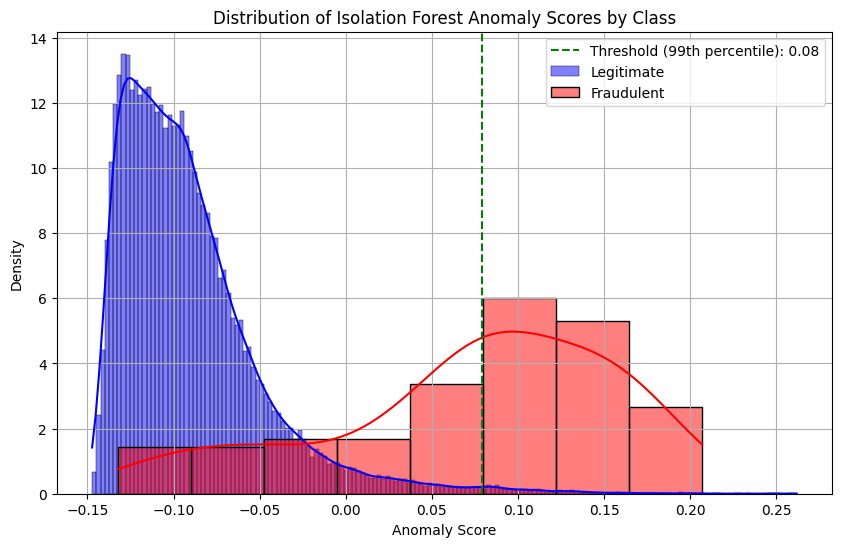

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get anomaly scores for legitimate and fraudulent transactions
iso_anomaly_score_legit = iso_anomaly_score[y_test == 0]
iso_anomaly_score_fraud = iso_anomaly_score[y_test == 1]

plt.figure(figsize=(10, 6))
sns.histplot(iso_anomaly_score_legit, color='blue', label='Legitimate', kde=True, stat='density', alpha=0.5)
sns.histplot(iso_anomaly_score_fraud, color='red', label='Fraudulent', kde=True, stat='density', alpha=0.5)

plt.axvline(x=iso_threshold, color='green', linestyle='--', label=f'Threshold (99th percentile): {iso_threshold:.2f}')

plt.title('Distribution of Isolation Forest Anomaly Scores by Class')
plt.xlabel('Anomaly Score')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()

This visualization helps illustrate the overlap in anomaly scores between legitimate and fraudulent transactions. A perfect model would show two distinct distributions with no overlap. The overlap indicates that many legitimate transactions receive high anomaly scores (false positives) and some fraudulent transactions receive low anomaly scores (false negatives), contributing to the model's challenges with precision and recall on this imbalanced dataset.

### Why Semi-Supervised Methods Struggle with This Dataset

Isolation Forest and GMM assume:
Fraud points are rare and structurally different from normal data.
But in credit card fraud:


*   Many fraud transactions are designed to look normal.
*   They lie inside dense regions of legitimate behavior.
*   Fraudsters intentionally mimic normal spending patterns.

So fraud is often rare and not statistically extreme
That breaks the core assumption of anomaly detection.

**Definition of Anomaly:** We were tempted to explore if the rarity or imbalanced nature of fraud data could be treated as an anomaly, but the experiments clearly showed that imbalancee ≠ anomaly
Both GMM and Isolation Forest define anomalies based on how much a data point deviates from the learned distribution of the *normal* class. If some fraudulent transactions are not drastically different from legitimate ones (i.e., they fall within the 'normal' distribution or near its boundaries), these models will struggle to distinguish them. They might learn to identify generic 'unusual' points, which can include legitimate but rare transactions, leading to false positives.

**Thresholding Trade-off:** The choice of anomaly threshold directly impacts the balance between precision and recall. To achieve a high recall (like GMM's 81% or Isolation Forest's 59%), the threshold often needs to be set generously, allowing more potential anomalies through. This inevitably increases the number of false positives, driving down precision. In fraud detection, there's often a business-specific cost associated with false positives vs. false negatives, and tuning this threshold is critical.

**Model Assumptions:**
    *   **Gaussian Mixture Model (GMM):** Assumes that the underlying distribution of the legitimate data can be well-represented by a mixture of Gaussian distributions. If the actual distribution of legitimate transactions is more complex, multimodal, or non-Gaussian in nature, GMM might not be able to accurately model 'normal' behavior, leading to inaccuracies in anomaly scoring.
    *   **Isolation Forest:** Works by isolating anomalies in fewer steps within a random forest-like structure. While effective for global outliers, it might struggle with 'inlier' anomalies (fraudulent transactions that are close to normal data points) or when the density of the normal class is very complex.

In summary, while GMM showed significantly better performance than Isolation Forest, especially with a PR-AUC of 0.7456, the very low precision (0.14) highlights the inherent challenge of detecting rare fraud events. These models, primarily focused on learning normal behavior, struggle to create a precise boundary for the minority class when the classes overlap or the anomaly patterns are subtle.